In [111]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBRegressor

pd.set_option('display.max_columns', None)

In [112]:
df = pd.read_csv("../dataset/student.csv")

In [113]:
df.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,reason,guardian,traveltime,studytime,failures,schoolsup,famsup,paid,activities,nursery,higher,internet,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,course,mother,2,2,0,yes,no,no,no,yes,yes,no,no,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,course,father,1,2,0,no,yes,no,no,no,yes,yes,no,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,other,mother,1,2,3,yes,no,yes,no,yes,yes,yes,no,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,home,mother,1,3,0,no,yes,yes,yes,yes,yes,yes,yes,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,home,father,1,2,0,no,yes,yes,no,yes,yes,no,no,4,3,2,1,2,5,4,6,10,10


In [114]:
# Simplified preprocessing (fixed order for dummies and drop)
for col in ["Mjob", "Fjob", "reason", "guardian"]:
    dummies = pd.get_dummies(df[col], prefix=col)
    df = pd.concat([df, dummies], axis=1)
    df.drop(columns=[col], inplace=True)

df = df.drop(columns=["school", "address"])

df["sex_male"] = df["sex"] == "M"
df["parent_together"] = df["Pstatus"] == "T"

mapping = {1: 60, 2: 210, 3: 450, 4: 720}
df["traveltime_minutes"] = df["traveltime"].map(mapping)
df["studytime_minutes"] = df["studytime"].map(mapping)

for col in ["schoolsup", "famsup", "paid", "activities", "nursery", "higher", "internet", "romantic"]:
    df[col] = df[col] == "yes"

for col in ["G1", "G2", "G3"]:
    df[col] = df[col] * 5

In [115]:
# Modeling: feature selection, split, train, cross-validation, evaluation (numeric columns only)
X = df.drop(columns=["G3"]).select_dtypes(include=[np.number])
y = df["G3"]

# Feature selection using RandomForest
selector = SelectFromModel(RandomForestRegressor(n_estimators=100, random_state=42), threshold="median")
selector.fit(X, y)
X_selected = selector.transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)

# Model training
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)
model.fit(X_train, y_train)

# Cross-validation
cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
print("CV RMSE:", np.sqrt(-cv_scores).mean())

# Evaluation on test set
y_pred = model.predict(X_test)
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("Test R2:", r2_score(y_test, y_pred))



CV RMSE: 7.083046064060532
Test RMSE: 8.156511387609072
Test R2: 0.8278779890292665


In [116]:
y_train_pred = model.predict(X_train)

print("Train R2:", r2_score(y_train, y_train_pred))
print("Test R2:", r2_score(y_test, y_pred))

Train R2: 0.9488007409765455
Test R2: 0.8278779890292665


In [117]:
def regression_accuracy(y_true, y_pred, tolerance=5):
    """
    Returns % of predictions within ±tolerance of actual value
    """
    correct = abs(y_true - y_pred) <= tolerance
    return correct.mean() * 100

# Example
acc_5 = regression_accuracy(y_test, y_pred, tolerance=5)
acc_10 = regression_accuracy(y_test, y_pred, tolerance=10)

print(f"Accuracy (±5 units): {acc_5:.2f}%")
print(f"Accuracy (±10 units): {acc_10:.2f}%")

Accuracy (±5 units): 71.29%
Accuracy (±10 units): 93.78%


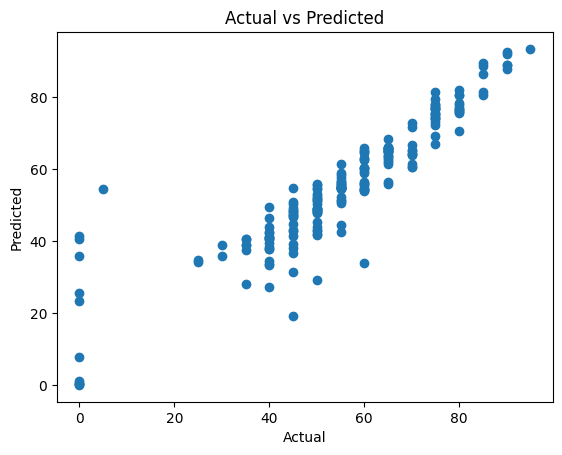

In [118]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

In [119]:
# XGBoost Regression Model Training and Evaluation
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict and evaluate
xgb_pred = xgb_model.predict(X_test)
print("XGBoost Test RMSE:", np.sqrt(mean_squared_error(y_test, xgb_pred)))
print("XGBoost Test R2:", r2_score(y_test, xgb_pred))

XGBoost Test RMSE: 9.30784050010477
XGBoost Test R2: 0.7758568525314331


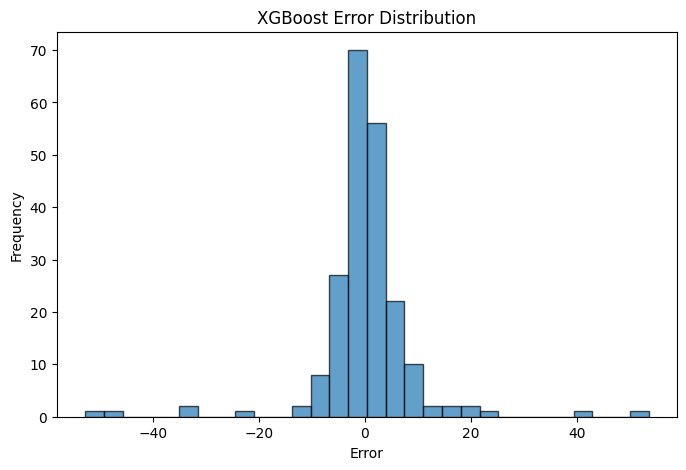

In [120]:
# Error distribution for XGBoost predictions
xgb_errors = y_test - xgb_pred
plt.figure(figsize=(8, 5))
plt.hist(xgb_errors, bins=30, edgecolor='k', alpha=0.7)
plt.title("XGBoost Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()